# Section Index
- **0.2** Load Data
- **0.3** Quick EDA
- **0.4** Review Length Distribution
- **1.0–1.8** Preprocessing (emoji→clean→tokenize→stopwords→lemmatize→processed_text)
- **1.45** Extra Stopwords
- **1.9** Vocabulary Size & Top Tokens  — *right after 1.8*
- **2.0** Label Encoding
- **2.1** Per-Class Summary
- **2.5** Text Data Augmentation
- **3.0** SBERT Embeddings
- **4.0** Train/Test Split
- **5.0** Models & Training
- **6.0** Evaluation
- **7.0** Top‑k
- **8.0** Cross‑Validation


In [ ]:
# 0.1 SETUP & INSTALLS
# If on Colab or a fresh env, run this once:
!pip install -q sentence-transformers emoji pyspellchecker

import re, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# NLP
import nltk
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Emoji & optional spelling correction
import emoji
from spellchecker import SpellChecker

# ML
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             top_k_accuracy_score)
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# Embeddings
from sentence_transformers import SentenceTransformer


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 77.3 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
# 0.2 LOAD DATA (EXCEL) — no edits needed
df = pd.read_excel("newdes.xlsx")

# Columns used
TEXT_COL  = "description"  # free-text reviews
LABEL_COL = "city"         # target label

# Keep a raw copy for demos
df["raw_text"] = df[TEXT_COL].astype(str)

print("Shape:", df.shape)
#df[[LABEL_COL, "theme/ point of interest", "raw_text"]].head()



Shape: (1015, 9)


# 0.3 Quick EDA

- Dataset shape & columns
- Class list and per-class counts (bar)
- Using `raw_text`/`processed_text` for lengths.

Shape (rows, cols): (1015, 9)
Columns: ['city', 'point_of_interest', 'description', 'district', 'province', 'review_link', 'rating', 'review_date', 'raw_text']
Number of classes: 9
Classes: ['Anuradhapura', 'Colombo', 'Ella', 'Galle', 'Jaffna', 'Kandy', 'Mirissa', 'Nuwara Eliya', 'Yala']


,count
city,
Anuradhapura,122
Colombo,125
Ella,117
Galle,120
Jaffna,120
Kandy,85
Mirissa,120
Nuwara Eliya,111
Yala,95


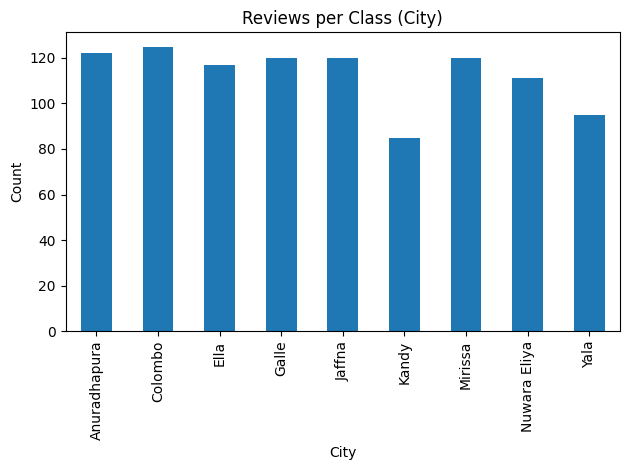

In [ ]:
# 0.3.1 EDA — dataset and class distribution
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("Shape (rows, cols):", df.shape)
print("Columns:", list(df.columns))

# Normalize label text for reporting only
_label_series = df[LABEL_COL].astype(str).str.strip().str.title()

classes = sorted(_label_series.unique().tolist())
print("Number of classes:", len(classes))
print("Classes:", classes)

counts = _label_series.value_counts().sort_index()
display(counts)

plt.figure()
counts.plot(kind="bar")
plt.title("Reviews per Class (City)")
plt.xlabel("City")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 0.4 Review Length Distribution
After creating `raw_text` (0.2) and `processed_text` (1.8), can run this to show length stats if needed

Raw text length stats (words):
count    1015.000000
mean       56.366502
std        53.877900
min         6.000000
25%        15.500000
50%        40.000000
75%        75.500000
max       380.000000
Name: raw_len, dtype: float64


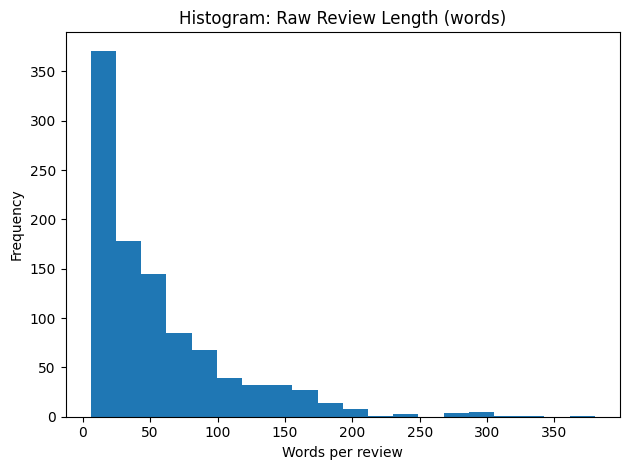

In [ ]:
# 0.4.1 Review length stats & histograms
def _word_count_series(text_series):
    return text_series.fillna("").astype(str).str.split().map(len)

if "raw_text" in df.columns:
    df["raw_len"] = _word_count_series(df["raw_text"])
    print("Raw text length stats (words):")
    print(df["raw_len"].describe())

if "processed_text" in df.columns:
    df["proc_len"] = _word_count_series(df["processed_text"])
    print("\nProcessed text length stats (words):")
    print(df["proc_len"].describe())

# Plot individually (one chart at a time)
if "raw_len" in df.columns:
    plt.figure()
    df["raw_len"].plot(kind="hist", bins=20)
    plt.title("Histogram: Raw Review Length (words)")
    plt.xlabel("Words per review")
    plt.ylabel("Frequency")
    plt.tight_layout(); plt.show()

if "proc_len" in df.columns:
    plt.figure()
    df["proc_len"].plot(kind="hist", bins=20)
    plt.title("Histogram: Processed Review Length (words)")
    plt.xlabel("Words per review")
    plt.ylabel("Frequency")
    plt.tight_layout(); plt.show()


In [ ]:
# 1.0 PREPROCESSING CONFIG
EN_STOP = set(stopwords.words("english"))
stemmer  = PorterStemmer()
lemma    = WordNetLemmatizer()
speller  = SpellChecker(distance=1)   # optional

# Toggles (change only if you want)
USE_SPELL_CORRECTION = False   # True = slower; can harm place names
USE_STEMMING         = False   # choose at most ONE of these:
USE_LEMMATIZATION    = True    # recommended


In [ ]:
# 1.1 EMOJI → TEXT (demojize). Mojibake will be cleaned in 1.2 anyway.
def demojize_text(s: str) -> str:
    return emoji.demojize(s, language="en")

df["demojized"] = df["raw_text"].apply(demojize_text)
df[["raw_text", "demojized"]].head()


,raw_text,demojized
0,Nice. The only real attraction in Colombo that...,Nice. The only real attraction in Colombo that...
1,A temple with interesting collections. One of ...,A temple with interesting collections. One of ...
2,Buddhist temple on Beira Lake used for meditat...,Buddhist temple on Beira Lake used for meditat...
3,Beautiful Buddhist temple in the city. Was a b...,Beautiful Buddhist temple in the city. Was a b...
4,Peaceful vibe. Such a nice peaceful temple whi...,Peaceful vibe. Such a nice peaceful temple whi...


In [ ]:
# 1.2 LOWERCASE & CLEAN (remove punctuation/specials, keep commas and spaces)
PUNCT_TO_KEEP = ","
def basic_clean(s: str) -> str:
    s = s.lower()
    s = re.sub(rf"[^a-z0-9 {re.escape(PUNCT_TO_KEEP)}]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["lower_alnum"] = df["demojized"].apply(basic_clean)
df[["demojized", "lower_alnum"]].head()


,demojized,lower_alnum
0,Nice. The only real attraction in Colombo that...,nice the only real attraction in colombo that ...
1,A temple with interesting collections. One of ...,a temple with interesting collections one of t...
2,Buddhist temple on Beira Lake used for meditat...,buddhist temple on beira lake used for meditat...
3,Beautiful Buddhist temple in the city. Was a b...,beautiful buddhist temple in the city was a be...
4,Peaceful vibe. Such a nice peaceful temple whi...,peaceful vibe such a nice peaceful temple whic...


In [ ]:
# 1.3 TOKENIZATION

import nltk
nltk.download("punkt")
nltk.download("punkt_tab")  # NEW: fixes LookupError for word_tokenize

def tokenize(s: str):
    return word_tokenize(s)

df["tokens"] = df["lower_alnum"].apply(tokenize)
df[["lower_alnum", "tokens"]].head()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,lower_alnum,tokens
0,nice the only real attraction in colombo that ...,"[nice, the, only, real, attraction, in, colomb..."
1,a temple with interesting collections one of t...,"[a, temple, with, interesting, collections, on..."
2,buddhist temple on beira lake used for meditat...,"[buddhist, temple, on, beira, lake, used, for,..."
3,beautiful buddhist temple in the city was a be...,"[beautiful, buddhist, temple, in, the, city, w..."
4,peaceful vibe such a nice peaceful temple whic...,"[peaceful, vibe, such, a, nice, peaceful, temp..."


In [ ]:
# 1.4 STOPWORD REMOVAL
def remove_stopwords(tokens):
    return [t for t in tokens if t not in EN_STOP and len(t) > 1]

df["no_stop"] = df["tokens"].apply(remove_stopwords)
df[["tokens", "no_stop"]].head()


,tokens,no_stop
0,"[nice, the, only, real, attraction, in, colomb...","[nice, real, attraction, colombo, worth, visit..."
1,"[a, temple, with, interesting, collections, on...","[temple, interesting, collections, one, visite..."
2,"[buddhist, temple, on, beira, lake, used, for,...","[buddhist, temple, beira, lake, used, meditati..."
3,"[beautiful, buddhist, temple, in, the, city, w...","[beautiful, buddhist, temple, city, beautiful,..."
4,"[peaceful, vibe, such, a, nice, peaceful, temp...","[peaceful, vibe, nice, peaceful, temple, middl..."


## 1.45 Extra Stopwords (Domain-Specific)  
Add any extra filler words or ultra-generic travel words you want to remove. **Keep them lowercase.**
After changing this list, re-run steps **1.4 → 1.8** to regenerate `processed_text`.

In [ ]:
# 1.45 Extra Stopwords
EXTRA_STOPWORDS = {
    "also","really","very","quite",
    "place","area","city","town",
    "amazing","nice","great","good","best","beautiful",
    "get","got","go","went","like","just","one","lot",
    # Add Sri Lanka generic tokens if they drown signal:
    "sri","lanka","srilanka"
}
try:
    EN_STOP |= EXTRA_STOPWORDS
except NameError:
    # In case 1.0 hasn't run yet; this will be superseded once 1.0 runs.
    EN_STOP = set(EXTRA_STOPWORDS)

print("Extra stopwords added:", len(EXTRA_STOPWORDS))


Extra stopwords added: 25


In [ ]:
# 1.6 (OPTIONAL) SPELLING — OFF by default (can distort city names)
def correct_spelling(tokens):
    corrected = []
    for t in tokens:
        if t.isalpha() and len(t) >= 4:
            corrected.append(speller.correction(t))
        else:
            corrected.append(t)
    return corrected

if USE_SPELL_CORRECTION:
    df["no_stop"] = df["no_stop"].apply(correct_spelling)

df["no_stop"].head()


,no_stop
0,"[nice, real, attraction, colombo, worth, visit..."
1,"[temple, interesting, collections, one, visite..."
2,"[buddhist, temple, beira, lake, used, meditati..."
3,"[beautiful, buddhist, temple, city, beautiful,..."
4,"[peaceful, vibe, nice, peaceful, temple, middl..."


In [ ]:
# 1.7 STEMMING / LEMMATIZATION (choose via toggles)
def stem_tokens(tokens):  return [stemmer.stem(t) for t in tokens]
def lemma_tokens(tokens): return [lemma.lemmatize(t) for t in tokens]

processed_tokens = df["no_stop"]
if USE_STEMMING:
    processed_tokens = processed_tokens.apply(stem_tokens)
if USE_LEMMATIZATION:
    processed_tokens = processed_tokens.apply(lemma_tokens)

df["processed_tokens"] = processed_tokens
df[["no_stop", "processed_tokens"]].head()


,no_stop,processed_tokens
0,"[nice, real, attraction, colombo, worth, visit...","[nice, real, attraction, colombo, worth, visit..."
1,"[temple, interesting, collections, one, visite...","[temple, interesting, collection, one, visited..."
2,"[buddhist, temple, beira, lake, used, meditati...","[buddhist, temple, beira, lake, used, meditati..."
3,"[beautiful, buddhist, temple, city, beautiful,...","[beautiful, buddhist, temple, city, beautiful,..."
4,"[peaceful, vibe, nice, peaceful, temple, middl...","[peaceful, vibe, nice, peaceful, temple, middl..."


In [ ]:
# 1.8 FINAL PROCESSED TEXT
df["processed_text"] = df["processed_tokens"].apply(lambda ts: " ".join(ts))
df[["raw_text", "processed_text"]].head()


,raw_text,processed_text
0,Nice. The only real attraction in Colombo that...,nice real attraction colombo worth visiting te...
1,A temple with interesting collections. One of ...,temple interesting collection one visited temp...
2,Buddhist temple on Beira Lake used for meditat...,buddhist temple beira lake used meditation res...
3,Beautiful Buddhist temple in the city. Was a b...,beautiful buddhist temple city beautiful place...
4,Peaceful vibe. Such a nice peaceful temple whi...,peaceful vibe nice peaceful temple middle busy...


In [ ]:
# 2.0 LABEL ENCODING (with cleaning to avoid missing cities)

# Clean up city column: strip spaces and fix casing
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip().str.title()

# Encode labels
le = LabelEncoder()
df["label_id"] = le.fit_transform(df[LABEL_COL])

num_classes = len(le.classes_)
print("Classes:", num_classes)
print("All classes:", le.classes_)

df[[LABEL_COL, "label_id"]].head()



Classes: 9
All classes: ['Anuradhapura' 'Colombo' 'Ella' 'Galle' 'Jaffna' 'Kandy' 'Mirissa'
 'Nuwara Eliya' 'Yala']


,city,label_id
0,Colombo,1
1,Colombo,1
2,Colombo,1
3,Colombo,1
4,Colombo,1


## 2.1 Per-Class Length & Balance Summary  

## 1.9 Vocabulary Size & Top Tokens  

In [ ]:
# 1.9 Vocabulary (from processed_text)
if "processed_text" in df.columns:
    tokens = df["processed_text"].fillna("").str.split()
    vocab = {}
    for toks in tokens:
        for t in toks:
            vocab[t] = vocab.get(t, 0) + 1
    print("Vocabulary size (processed):", len(vocab))
    N = 25
    top = sorted(vocab.items(), key=lambda kv: kv[1], reverse=True)[:N]
    print(f"Top {N} tokens (token, count):")
    for tok, ct in top:
        print(f"{tok:20s} {ct}")
else:
    print("Run preprocessing through 1.8 to create processed_text.")


Vocabulary size (processed): 4080
Top 25 tokens (token, count):
2022                 311
view                 253
visited              213
beach                211
place                205
see                  194
one                  190
visit                190
great                185
2023                 184
sri                  183
park                 173
experience           159
tour                 159
beautiful            157
day                  157
time                 154
lanka                152
walk                 133
water                129
temple               126
jeep                 124
peaceful             121
around               121
spot                 120


In [ ]:
# 2.1 Per-class counts and average lengths
import pandas as pd
def _safe_mean(s): return float(s.mean()) if len(s) else float('nan')
_label_series = df[LABEL_COL].astype(str).str.strip().str.title()

rows = []
for city, sub in df.assign(_label=_label_series).groupby("_label"):
    row = {"city": city, "count": len(sub)}
    if "raw_len" in sub.columns:  row["avg_raw_words"] = _safe_mean(sub["raw_len"])
    if "proc_len" in sub.columns: row["avg_proc_words"] = _safe_mean(sub["proc_len"])
    rows.append(row)

eda_summary = pd.DataFrame(rows).sort_values("city").reset_index(drop=True)
display(eda_summary)


,city,count,avg_raw_words
0,Anuradhapura,122,35.180328
1,Colombo,125,47.736000
2,Ella,117,83.324786
3,Galle,120,46.158333
4,Jaffna,120,34.150000
5,Kandy,85,55.141176
6,Mirissa,120,65.275000
7,Nuwara Eliya,111,43.144144
8,Yala,95,107.978947


## 2.5 Text Data Augmentation for Minority Classes  
Augment text (create **new synthetic reviews**) to **reach a target count per class**.
Techniques used: synonym replacement (WordNet), random swap, random deletion (small).
**How to use:**
- Set `APPLY_AUGMENTATION=True` and `TARGET_PER_CLASS` (e.g., 60).
- Augmentation is applied on the **raw_text** (if present) so preprocessing still runs.
- The augmented rows inherit other columns; a new column `is_augmented=True` marks them.


In [ ]:
# 2.5.1 Augmentation utils
import random
from nltk.corpus import wordnet as wn

def _synonyms(word):
    syns = set()
    for syn in wn.synsets(word):
        for l in syn.lemmas():
            w = l.name().replace('_', ' ').lower()
            if w != word and w.isalpha():
                syns.add(w)
    return list(syns)

def aug_synonym_replacement(words, n=1):
    words = words[:]
    candidates = [w for w in words if w.isalpha() and len(w)>3]
    random.shuffle(candidates)
    replaced = 0
    for w in candidates:
        syns = _synonyms(w.lower())
        if syns:
            words = [random.choice(syns) if (tok==w and replaced<n) else tok for tok in words]
            replaced += 1
        if replaced>=n: break
    return words

def aug_random_swap(words, n=1):
    words = words[:]
    for _ in range(n):
        if len(words) < 2: break
        i, j = random.sample(range(len(words)), 2)
        words[i], words[j] = words[j], words[i]
    return words

def aug_random_deletion(words, p=0.05):
    if len(words)==1: return words
    return [w for w in words if random.random() > p] or words[:1]

def make_variant(text):
    toks = text.split()
    if len(toks) < 5:
        return text  # too short to augment safely
    # Apply a small combo
    variant = aug_synonym_replacement(toks, n=1)
    variant = aug_random_swap(variant, n=1)
    variant = aug_random_deletion(variant, p=0.03)
    return " ".join(variant)


In [ ]:
# 2.5.2 Apply augmentation to reach TARGET_PER_CLASS
from collections import Counter
import pandas as pd
import numpy as np

APPLY_AUGMENTATION = True   # <-- set True to enable
TARGET_PER_CLASS   = 127      # <-- e.g., target rows per city

def augment_to_target(df_in, label_col, text_col, target_per_class):
    # normalize labels for grouping
    labels = df_in[label_col].astype(str).str.strip().str.title()
    df_norm = df_in.copy()
    df_norm[label_col] = labels

    groups = df_norm.groupby(label_col)
    parts = []
    for city, sub in groups:
        need = target_per_class - len(sub)
        parts.append(sub)
        if need > 0:
            # Sample base texts with replacement, then augment
            base = sub[text_col].fillna("").astype(str).tolist()
            base = [t for t in base if t.strip()]
            if not base:
                continue
            aug_rows = []
            for _ in range(need):
                seed = random.choice(base)
                variant = make_variant(seed)
                row = sub.sample(1, replace=True, random_state=random.randint(1,99999)).iloc[0].copy()
                row[text_col] = variant
                row["is_augmented"] = True
                aug_rows.append(row)
            if aug_rows:
                parts.append(pd.DataFrame(aug_rows))
    out = pd.concat(parts, axis=0).reset_index(drop=True)
    return out

# Choose source dataframe and text column
_text_candidates = ["raw_text", "description", "text", "review"]
_text_col = None
for cand in _text_candidates:
    if cand in df.columns:
        _text_col = cand; break

if APPLY_AUGMENTATION and _text_col is not None:
    df_aug = augment_to_target(df, LABEL_COL, _text_col, TARGET_PER_CLASS)
    print("Augmentation applied. New class counts:")
    print(df_aug[LABEL_COL].astype(str).str.strip().str.title().value_counts().sort_index())
else:
    print("Augmentation not applied. Set APPLY_AUGMENTATION=True and ensure a valid text column is present.")


Augmentation applied. New class counts:
city
Anuradhapura    127
Colombo         127
Ella            127
Galle           127
Jaffna          127
Kandy           127
Mirissa         127
Nuwara Eliya    127
Yala            127
Name: count, dtype: int64


In [ ]:
# 2.6 Auto-switch to augmented data
if 'df_aug' in globals():
    df = df_aug.copy()
    print("Auto-switch: using augmented dataframe for downstream steps (df = df_aug).")
else:
    print("Auto-switch: augmentation not enabled; continuing with original df.")

Auto-switch: using augmented dataframe for downstream steps (df = df_aug).


In [ ]:
# 3.0 SBERT EMBEDDINGS
sbert = SentenceTransformer("all-MiniLM-L6-v2")
texts = df["processed_text"].astype(str).tolist()
X_emb = sbert.encode(texts, normalize_embeddings=False)
X_emb = np.asarray(X_emb)
y = df["label_id"].values
X_emb.shape, len(y)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

((1143, 384), 1143)

In [ ]:
# 4.0 SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_emb, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape


((914, 384), (229, 384))

In [ ]:
# 5.0 MODELS
from sklearn.pipeline import Pipeline
models = {
    "LinearSVM": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", LinearSVC(C=1.0, class_weight="balanced", random_state=42))
    ]),
    "LogReg": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=-1))
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, random_state=42, class_weight="balanced_subsample", n_jobs=-1
    ),
    "GaussianNB": GaussianNB()
}
list(models.keys())


['LinearSVM', 'LogReg', 'RandomForest', 'GaussianNB']


=== LinearSVM ===
Accuracy : 0.808 | Precision : 0.807 | Recall : 0.807 | Macro-F1 : 0.805

Classification Report:
              precision    recall  f1-score   support

Anuradhapura       0.88      0.88      0.88        25
     Colombo       0.56      0.56      0.56        25
        Ella       0.87      1.00      0.93        26
       Galle       0.83      0.73      0.78        26
      Jaffna       0.69      0.69      0.69        26
       Kandy       0.69      0.72      0.71        25
     Mirissa       0.93      0.96      0.94        26
Nuwara Eliya       0.86      0.72      0.78        25
        Yala       0.96      1.00      0.98        25

    accuracy                           0.81       229
   macro avg       0.81      0.81      0.81       229
weighted avg       0.81      0.81      0.81       229



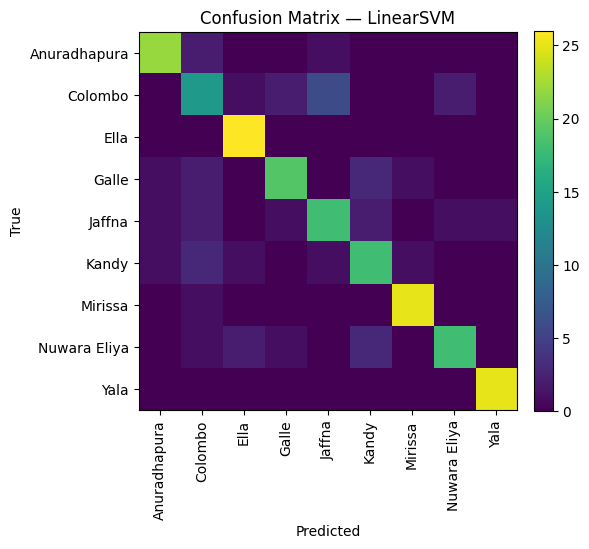


=== LogReg ===
Accuracy : 0.838 | Precision : 0.838 | Recall : 0.838 | Macro-F1 : 0.836

Classification Report:
              precision    recall  f1-score   support

Anuradhapura       0.92      0.96      0.94        25
     Colombo       0.73      0.64      0.68        25
        Ella       0.89      0.92      0.91        26
       Galle       0.85      0.65      0.74        26
      Jaffna       0.72      0.81      0.76        26
       Kandy       0.76      0.76      0.76        25
     Mirissa       0.93      1.00      0.96        26
Nuwara Eliya       0.74      0.80      0.77        25
        Yala       1.00      1.00      1.00        25

    accuracy                           0.84       229
   macro avg       0.84      0.84      0.84       229
weighted avg       0.84      0.84      0.84       229



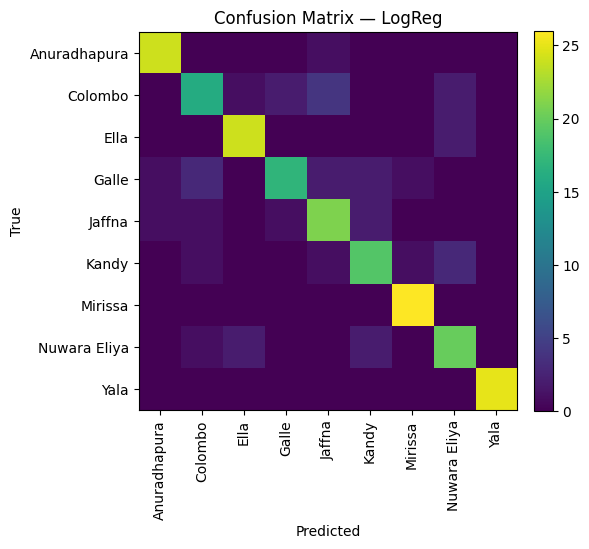


=== RandomForest ===
Accuracy : 0.843 | Precision : 0.842 | Recall : 0.843 | Macro-F1 : 0.839

Classification Report:
              precision    recall  f1-score   support

Anuradhapura       0.86      1.00      0.93        25
     Colombo       0.80      0.64      0.71        25
        Ella       0.93      0.96      0.94        26
       Galle       0.81      0.65      0.72        26
      Jaffna       0.70      0.73      0.72        26
       Kandy       0.88      0.84      0.86        25
     Mirissa       0.83      0.96      0.89        26
Nuwara Eliya       0.77      0.80      0.78        25
        Yala       1.00      1.00      1.00        25

    accuracy                           0.84       229
   macro avg       0.84      0.84      0.84       229
weighted avg       0.84      0.84      0.84       229



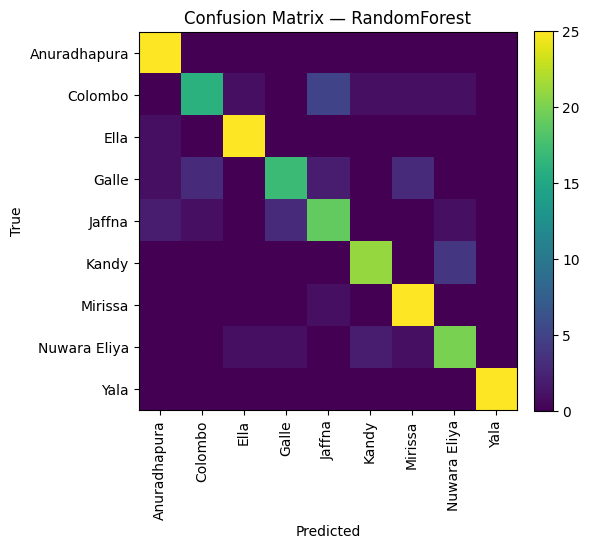


=== GaussianNB ===
Accuracy : 0.755 | Precision : 0.756 | Recall : 0.756 | Macro-F1 : 0.754

Classification Report:
              precision    recall  f1-score   support

Anuradhapura       0.92      0.92      0.92        25
     Colombo       0.71      0.60      0.65        25
        Ella       0.74      0.88      0.81        26
       Galle       0.65      0.58      0.61        26
      Jaffna       0.58      0.54      0.56        26
       Kandy       0.75      0.72      0.73        25
     Mirissa       0.81      0.81      0.81        26
Nuwara Eliya       0.63      0.76      0.69        25
        Yala       1.00      1.00      1.00        25

    accuracy                           0.76       229
   macro avg       0.76      0.76      0.75       229
weighted avg       0.75      0.76      0.75       229



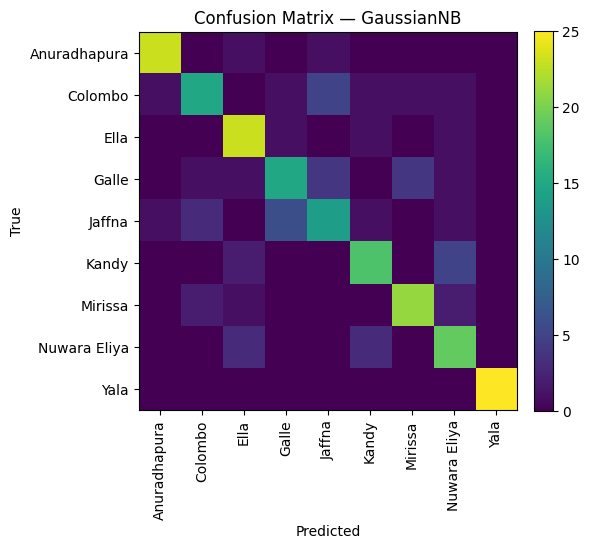

,model,acc,prec,rec,f1
2,RandomForest,0.842795,0.842087,0.843077,0.839459
1,LogReg,0.838428,0.838077,0.838291,0.835850
0,LinearSVM,0.807860,0.806886,0.807179,0.805408
3,GaussianNB,0.755459,0.755862,0.756410,0.753859


In [ ]:
# 6.0 EVALUATE
def evaluate_model(name, clf, Xtr, ytr, Xte, yte, label_names):
    clf.fit(Xtr, ytr)
    yp = clf.predict(Xte)

    acc  = accuracy_score(yte, yp)
    prec = precision_score(yte, yp, average="macro", zero_division=0)
    rec  = recall_score(yte, yp, average="macro", zero_division=0)
    f1   = f1_score(yte, yp, average="macro", zero_division=0)

    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc:.3f} | Precision : {prec:.3f} | Recall : {rec:.3f} | Macro-F1 : {f1:.3f}")
    print("\nClassification Report:")
    print(classification_report(yte, yp, target_names=label_names, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(yte, yp, labels=range(len(label_names)))
    fig, ax = plt.subplots(figsize=(6,6))
    im = ax.imshow(cm, interpolation='nearest')
    ax.set_title(f"Confusion Matrix — {name}")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    ax.set_xticks(range(len(label_names))); ax.set_yticks(range(len(label_names)))
    ax.set_xticklabels(label_names, rotation=90); ax.set_yticklabels(label_names)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout(); plt.show()

    return {"model": name, "acc": acc, "prec": prec, "rec": rec, "f1": f1, "clf": clf}

# Run evaluation for all models
results_holdout = []
for name, clf in models.items():
    res = evaluate_model(name, clf, X_train, y_train, X_test, y_test, le.classes_)
    results_holdout.append(res)

# Build DataFrame and sort by F1
results_df = pd.DataFrame(
    [{k: v for k, v in res.items() if k != "clf"} for res in results_holdout]
)
results_df.sort_values("f1", ascending=False)



In [ ]:
# ------------------------------------------------------------
# 5-FOLD CROSS VALIDATION FOR ALL 4 MODELS
# ------------------------------------------------------------
from sklearn.model_selection import cross_val_score, StratifiedKFold

models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVM": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():
    print(f"* Running {name}...")
    scores = cross_val_score(model, X_emb, y, cv=cv, scoring='accuracy')
    results[name] = scores
    print(f"Accuracies per fold: {scores}")
    print(f"Average Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})\n")

# Optional summary table
print("Cross-Validation Summary:")
for name, scores in results.items():
    print(f"{name:20s}  Mean={scores.mean():.4f}  Std={scores.std():.4f}")


* Running Naive Bayes...
Accuracies per fold: [0.75982533 0.76419214 0.73362445 0.77192982 0.72807018]
Average Accuracy: 0.7515 (+/- 0.0174)

* Running Logistic Regression...
Accuracies per fold: [0.7860262  0.81222707 0.76855895 0.82017544 0.75877193]
Average Accuracy: 0.7892 (+/- 0.0239)

* Running Linear SVM...
Accuracies per fold: [0.79912664 0.86899563 0.8209607  0.8377193  0.84210526]
Average Accuracy: 0.8338 (+/- 0.0232)

* Running Random Forest...
Accuracies per fold: [0.81659389 0.8209607  0.80349345 0.82894737 0.81578947]
Average Accuracy: 0.8172 (+/- 0.0083)

Cross-Validation Summary:
Naive Bayes           Mean=0.7515  Std=0.0174
Logistic Regression   Mean=0.7892  Std=0.0239
Linear SVM            Mean=0.8338  Std=0.0232
Random Forest         Mean=0.8172  Std=0.0083


In [ ]:
# 7.0 TOP-3 ACCURACY FOR LINEARSVM
svm_pipe = next(r["clf"] for r in results_holdout if r["model"]=="LinearSVM")
scores = svm_pipe.named_steps["clf"].decision_function(
    svm_pipe.named_steps["scaler"].transform(X_test)
)
atk3 = top_k_accuracy_score(y_test, scores, k=3, labels=svm_pipe.named_steps["clf"].classes_)
print(f"Top-3 Accuracy (LinearSVM): {atk3:.3f}")


Top-3 Accuracy (LinearSVM): 0.917


In [ ]:
# # === 9.0 FINAL RECOMMENDER (whole paragraph once) — minimal, self-contained ===
# import numpy as np
# from sklearn.preprocessing import LabelEncoder, StandardScaler
# from sklearn.pipeline import Pipeline
# from sklearn.svm import LinearSVC

# # 1) labels (hotel/city encoder)
# LABEL_COL = "city"  # keep as-is for your dataset
# le = LabelEncoder()
# y  = le.fit_transform(df[LABEL_COL].astype(str).str.strip().str.title().values)

# # 2) SBERT embeddings for ALL rows (uses your existing 'processed_text')
# X_emb = sbert.encode(df["processed_text"].astype(str).tolist(), normalize_embeddings=False)

# # 3) train final model on ALL data
# final_svm = Pipeline([
#     ("scaler", StandardScaler(with_mean=False)),
#     ("clf", LinearSVC(C=1.0, class_weight="balanced", random_state=42))
# ])
# final_svm.fit(X_emb, y)

# # 4) id -> city mapping
# id_to_city = dict(zip(range(len(le.classes_)), le.classes_))

# # 5) whole-paragraph recommender
# def recommend_topk(text: str, k: int = 3):
#     emb = sbert.encode([text], normalize_embeddings=False)                 # (1, 384)
#     Z   = final_svm.named_steps["scaler"].transform(emb)                   # (1, 384)
#     scores = final_svm.named_steps["clf"].decision_function(Z)[0]          # (n_classes,)
#     idx = np.argsort(-scores)[:k]
#     labels = final_svm.named_steps["clf"].classes_[idx]
#     return [id_to_city[i] for i in labels]

# # demo
# user_input = input("Enter your travel preferences: ")
# print("\nTop 3 (9.0 FINAL, whole paragraph):")
# print(recommend_topk(user_input))


In [ ]:
# === 9.1 ROBUST (sentence-by-sentence) + POIs (simple version, SELF-CONTAINED) ===

from nltk.tokenize import sent_tokenize
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

# ---------- TRAIN SVM AGAIN (so this code can run alone) ----------

LABEL_COL = "city"  # make sure this matches your df

# 1) Encode labels (cities)
le = LabelEncoder()
y = le.fit_transform(
    df[LABEL_COL].astype(str).str.strip().str.title().values
)

# 2) SBERT embeddings for ALL rows (using your processed_text column)
X_emb = sbert.encode(
    df["processed_text"].astype(str).tolist(),
    normalize_embeddings=False
)

# 3) Train SVM model on all data
final_svm = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LinearSVC(C=1.0, class_weight="balanced", random_state=42)),
])
final_svm.fit(X_emb, y)

# 4) id -> city mapping
id_to_city = dict(zip(range(len(le.classes_)), le.classes_))


# ---------- ROBUST sentence-by-sentence RECOMMENDER ----------

def recommend_topk_robust(text: str, k: int = 3):
    """
    Split paragraph -> sentences, SBERT-encode each, scale, SVM scores per sentence,
    sum scores across sentences, take top-k, map IDs -> city names.
    Returns: list[str] of k city names.
    """
    # 1) split into sentences (each sentence = one idea)
    sents = [s.strip() for s in sent_tokenize(text) if s.strip()]
    if not sents:
        sents = [text.strip()]

    # 2) SBERT embeddings for EACH sentence  (n_sent x 384)
    emb = sbert.encode(sents, normalize_embeddings=False)

    # 3) scale using the SAME scaler used in training
    Z = final_svm.named_steps["scaler"].transform(emb)

    # 4) get SVM scores per sentence for each class  (n_sent x n_classes)
    sent_scores = final_svm.named_steps["clf"].decision_function(Z)

    # 5) add sentence scores -> one vector per class  (n_classes)
    agg = sent_scores.sum(axis=0)

    # 6) pick top-k classes and map model IDs -> city names
    idx = np.argsort(-agg)[:k]
    labels = final_svm.named_steps["clf"].classes_[idx]
    return [id_to_city[i] for i in labels]


# ----- POI helpers (display-only; do NOT call inside recommender) -----

def unique_pois_for_cities(df_in, cities, label_col='city', poi_col='point_of_interest'):
    """
    For each city, return UNIQUE POIs (no repeats). DataFrame not modified.
    """
    out = {}
    lab = df_in[label_col].astype(str).str.strip().str.title()
    tmp = df_in.copy()
    tmp[label_col] = lab
    for city in cities:
        ckey = str(city).strip().title()
        mask = tmp[label_col] == ckey
        if poi_col not in tmp.columns:
            out[city] = []
            continue
        pois = (tmp.loc[mask, poi_col]
                  .dropna().astype(str).str.strip()
                  .replace('', np.nan).dropna()
                  .unique())
        out[city] = sorted(pois.tolist())
    return out


def print_pois_by_city(df_in, cities, label_col='city', poi_col='point_of_interest', max_per_city=None):
    """
    Pretty-print unique POIs per predicted city.
    """
    mapping = unique_pois_for_cities(df_in, cities, label_col, poi_col)
    for city, pois in mapping.items():
        print(f"\nPlaces to visit in {city}:")
        if not pois:
            print("  (no POIs found in dataset)")
            continue
        if max_per_city is not None:
            pois = pois[:max_per_city]
        for p in pois:
            print(" -", p)


# ----- DEMO: robust prediction + POIs -----

user_input = input("Enter your travel preferences: ")
topk_robust = recommend_topk_robust(user_input, k=3)
print("\nTop 3 (ROBUST, sentence-by-sentence):", topk_robust)

# show places (unique POIs) for those cities
print_pois_by_city(df, topk_robust, label_col=LABEL_COL,
                   poi_col='point_of_interest', max_per_city=12)


Enter your travel preferences: Hey, I'm planning a family vacation to Sri Lanka next summer with my wife and two little ones (ages 5 and 7). We're dreaming of lazy days on gorgeous, calm beaches with shallow, crystal-clear waters for safe kid-friendly swimming and building epic sandcastles, but we also want to immerse in the cool, misty highlands with those iconic rolling green tea hills—think easy, shaded strolls through plantations to watch tea pickers at work and sample fresh brews at a cozy factory. Add in a few gentle waterfall stops for quick picnics with misty views (nothing steep or long), and cap it with a relaxed wildlife safari in a shaded jeep to spot playful elephants and perhaps a sneaky leopard, all low-key and with breaks for the kids. Suggest three destinations that weave this together seamlessly—beaches, highlands tea magic, waterfalls, and safari thrills—keeping it super family-oriented and not too adventurous?

Top 3 (ROBUST, sentence-by-sentence): ['Yala', 'Nuwara 

In [ ]:
def explain_predictions(text, topk_cities, top_n_sentences=3):
    """
    For each predicted city, show which sentences contributed the most.
    Output is human-friendly (no numbers).
    """

    sents = [s.strip() for s in sent_tokenize(text) if s.strip()]
    if not sents:
        sents = [text.strip()]

    # Encode each sentence
    emb = sbert.encode(sents, normalize_embeddings=False)
    Z = final_svm.named_steps["scaler"].transform(emb)

    # SVM scores for each sentence and each class
    sent_scores = final_svm.named_steps["clf"].decision_function(Z)

    # City → model ID
    city_to_id = {id_to_city[i]: i for i in id_to_city}

    explanations = {}

    for city in topk_cities:
        class_id = city_to_id[city]

        # Scores for this class across all sentences
        class_scores = sent_scores[:, class_id]

        # Pick best sentences
        best_idx = np.argsort(-class_scores)[:top_n_sentences]

        explanations[city] = [sents[i] for i in best_idx]

    return explanations


In [ ]:
# ---- Explainability ----
print("\n--- Why these cities were selected? ---")
explanations = explain_predictions(user_input, topk_robust, top_n_sentences=2)

for city, sent_list in explanations.items():
    print(f"\n* Why {city}?")
    for s in sent_list:
        print(f" - Matched your preference: \"{s}\"")



--- Why these cities were selected? ---

* Why Yala?
 - Matched your preference: "Add in a few gentle waterfall stops for quick picnics with misty views (nothing steep or long), and cap it with a relaxed wildlife safari in a shaded jeep to spot playful elephants and perhaps a sneaky leopard, all low-key and with breaks for the kids."
 - Matched your preference: "Suggest three destinations that weave this together seamlessly—beaches, highlands tea magic, waterfalls, and safari thrills—keeping it super family-oriented and not too adventurous?"

* Why Nuwara Eliya?
 - Matched your preference: "Hey, I'm planning a family vacation to Sri Lanka next summer with my wife and two little ones (ages 5 and 7)."
 - Matched your preference: "We're dreaming of lazy days on gorgeous, calm beaches with shallow, crystal-clear waters for safe kid-friendly swimming and building epic sandcastles, but we also want to immerse in the cool, misty highlands with those iconic rolling green tea hills—think easy,

In [ ]:
# Save once (after training)
import joblib
joblib.dump(final_svm, "final_svm.joblib")
joblib.dump(id_to_city, "id_to_city.joblib")

# Later / after restart: load instead of retraining
# final_svm = joblib.load("final_svm.joblib")
# id_to_city = joblib.load("id_to_city.joblib")



['id_to_city.joblib']

### ACCOMMODATION

In [ ]:
FILENAME = "accommodation.xlsx"


In [ ]:
#step 1

FILENAME = "accommodation.xlsx"
print("Step 1: Load & preprocess (no dedupe)...")

import pandas as pd, numpy as np, re

def _default_preprocess_text(s: str) -> str:
    s = "" if s is None or (isinstance(s, float) and pd.isna(s)) else str(s)
    s = s.lower()
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

preprocess_text_accom = globals().get("preprocess_text", _default_preprocess_text)

df = pd.read_excel(FILENAME)
df.columns = df.columns.astype(str).str.strip()
df = df.rename(columns={
    "Name":"Hotel", "Description":"Description", "City":"City",
    "Budget":"Budget", "Distance_per_city":"DistanceToCenter",
    "link":"Link", "Link":"Link"
})

for col in ["City","Hotel","Description"]:
    if col not in df.columns:
        raise ValueError(f"Missing column: {col}. Columns found: {list(df.columns)}")

for col in ["Budget","DistanceToCenter","Link"]:
    if col not in df.columns: df[col] = np.nan

df["Description"] = df["Description"].astype(str).map(preprocess_text_accom)

def budget_to_float(x):
    if pd.isna(x): return np.nan
    s = str(x)
    s = re.sub(r"[^\d\.\-]", "", s)
    if s.count(".") > 1:
        parts = s.split(".")
        s = "".join(parts[:-1]) + "." + parts[-1]
    try: return float(s)
    except: return np.nan

df["Budget"] = df["Budget"].map(budget_to_float)

def dist_to_km(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().lower()
    m = re.search(r'([-+]?\\d*\\.?\\d+)', s)
    if not m: return np.nan
    val = float(m.group(1))
    if "mile" in s: val *= 1.60934
    elif ("km" not in s) and re.search(r'(^|\\s|\\d)m($|\\s)', s): val /= 1000.0
    return val

df["DistanceToCenter"] = df["DistanceToCenter"].map(dist_to_km)

df = df[df["Description"].str.len()>0].reset_index(drop=True)

print("Step 1 done.")
print("Parsed Budget  → float count:", df["Budget"].notna().sum(), "/", len(df))
print("Parsed Distance→ km   count:", df["DistanceToCenter"].notna().sum(), "/", len(df))
df.head(3)

Step 1: Load & preprocess (no dedupe)...
Step 1 done.
Parsed Budget  → float count: 508 / 508
Parsed Distance→ km   count: 0 / 508


,City,Hotel,Budget,Description,DistanceToCenter,Link
0,Colombo,The Ocean Colombo,102.0,the ocean colombo is located facing the vast e...,NaN,https://www.tripadvisor.com/Hotel_Review-g2939...
1,Colombo,The Ocean Colombo,102.0,this summary was created by ai based on recent...,NaN,https://www.tripadvisor.com/Hotel_Review-g2939...
2,Colombo,ME Colombo,57.0,me colombo is a design hotel in the heart of c...,NaN,https://www.tripadvisor.com/Hotel_Review-g2939...


=== Elbow Method (Budget) ===


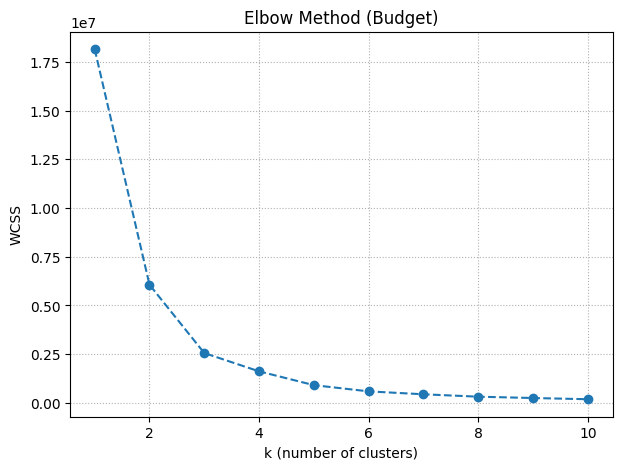


Suggested number of clusters (Elbow) = 3


In [ ]:
# === Simple Elbow Method (diagnostic only) ===
print("=== Elbow Method (Budget) ===")

import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# detect budget column
def _detect_budget_column(frame):
    cand = [c for c in frame.columns if isinstance(c, str)]
    by_name = [c for c in cand if re.search(r"(budget|price|cost|amount|payment|fare)", c, flags=re.I)]
    numeric_cols = frame.select_dtypes(include=["number"]).columns.tolist()
    by_name_numeric = [c for c in by_name if c in numeric_cols]
    if by_name_numeric: return by_name_numeric[0]
    if numeric_cols: return numeric_cols[0]
    raise ValueError("No numeric budget-like column found.")

try: BUDGET_COL
except NameError: BUDGET_COL = None
if BUDGET_COL is None: BUDGET_COL = _detect_budget_column(df)

vals = pd.to_numeric(df[BUDGET_COL], errors="coerce")
mask = np.isfinite(vals) & (vals >= 0)
X = vals[mask].to_numpy().reshape(-1, 1)

# compute WCSS
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    wcss.append(km.inertia_)

# plot elbow
plt.figure(figsize=(7,5))
plt.plot(range(1, 11), wcss, marker="o", linestyle="--")
plt.title("Elbow Method (Budget)")
plt.xlabel("k (number of clusters)")
plt.ylabel("WCSS")
plt.grid(True, linestyle=":")
plt.show()

# Knee point (distance method)
ks = np.arange(1, 11)
x1, y1 = ks[0], wcss[0]
x2, y2 = ks[-1], wcss[-1]

num = np.abs((y2 - y1)*ks - (x2 - x1)*np.array(wcss) + (x2*y1 - y2*x1))
den = np.sqrt((y2 - y1)**2 + (x2 - x1)**2)
elbow_k = int(ks[np.argmax(num)])

print(f"\nSuggested number of clusters (Elbow) = {elbow_k}")



=== K-Means on Budget: clustering + analytics ===
[INFO] Budget column: Budget | k = 3

=== Cluster summary (ascending by center) ===
 cluster  count   min    max       mean  median        std     center   tier  pct_of_valid
       1    348  11.0  186.0  88.908046    83.0  48.215925  88.908046    Low          68.5
       2    128 195.0  492.0 285.546875   261.5  71.656646 285.546875 Medium          25.2
       0     32 582.0 1244.0 773.500000   709.5 188.468531 773.500000   High           6.3

Approximate budget breakpoints (midpoints between cluster centers):
  Boundary 1: ~187.23
  Boundary 2: ~529.52

Silhouette score: 0.645


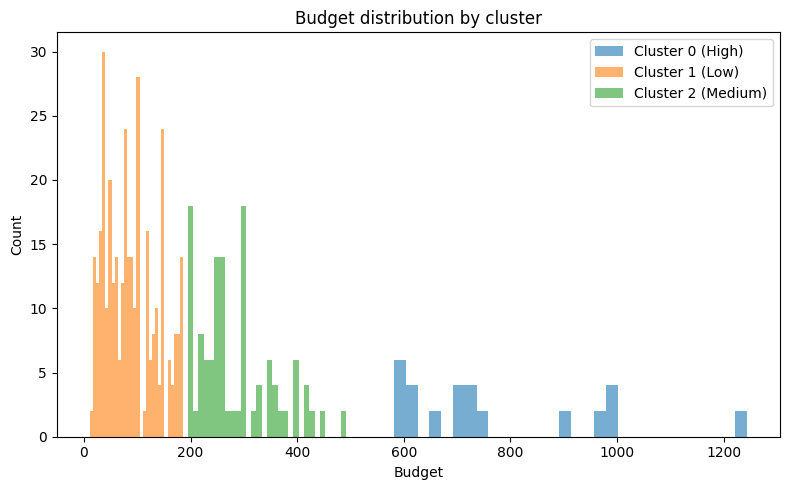

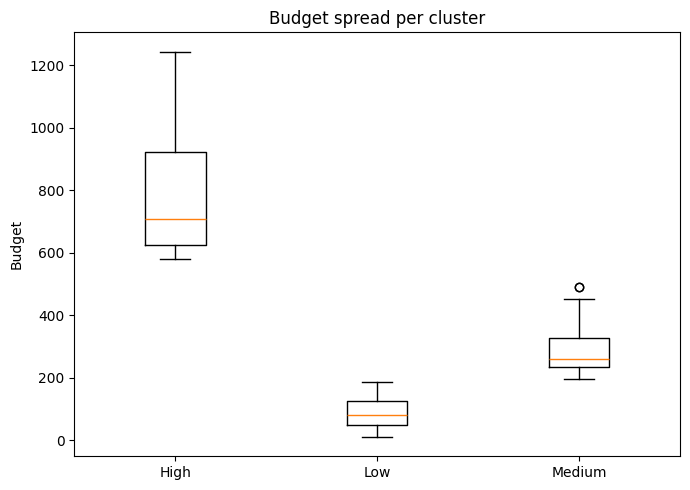


[Done] Added columns: BudgetCluster_k (id), BudgetTier_k (name).


In [ ]:
#step 8

# === Step Y: K-Means on Budget with rich analytics (after inspecting elbow) ===
print("=== K-Means on Budget: clustering + analytics ===")

import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# -----------------------------
# 0) Choose k
# -----------------------------
# Option A (recommended): lock to 3 for L/M/H
CHOSEN_K = 3

# Option B: if you want to adopt the elbow suggestion automatically, uncomment:
# try:
#     CHOSEN_K = int(elbow_k)
# except NameError:
#     CHOSEN_K = 3

# -----------------------------
# 1) Detect/confirm budget column
# -----------------------------
def _detect_budget_column(frame: pd.DataFrame):
    cand = [c for c in frame.columns if isinstance(c, str)]
    by_name = [c for c in cand if re.search(r"(budget|price|cost|amount|payment|fare)", c, flags=re.I)]
    numeric_cols = frame.select_dtypes(include=["number"]).columns.tolist()
    by_name_numeric = [c for c in by_name if c in numeric_cols]
    if by_name_numeric:
        return by_name_numeric[0]
    if numeric_cols:
        var = frame[numeric_cols].var(numeric_only=True).fillna(0.0).sort_values(ascending=False)
        if len(var):
            return var.index[0]
    raise ValueError("No numeric budget-like column found.")

# Use the same column the elbow reported if available; else detect
try:
    BUDGET_COL
except NameError:
    BUDGET_COL = None
if BUDGET_COL is None:
    BUDGET_COL = _detect_budget_column(df)

print(f"[INFO] Budget column: {BUDGET_COL} | k = {CHOSEN_K}")

vals = pd.to_numeric(df[BUDGET_COL], errors="coerce")
mask = np.isfinite(vals) & (vals >= 0)
X = vals[mask].to_numpy().reshape(-1, 1)
if X.size == 0:
    raise RuntimeError(f"No usable numeric values in '{BUDGET_COL}'.")

# -----------------------------
# 2) Fit K-Means
# -----------------------------
km = KMeans(n_clusters=CHOSEN_K, init="k-means++", random_state=42, n_init=10)
labels_fit = km.fit_predict(X)

# Align back to full df length
labels_full = np.full(len(df), fill_value=np.nan)
labels_full[np.where(mask)[0]] = labels_fit
df["BudgetCluster_k"] = labels_full

# Tier naming
centers = km.cluster_centers_.reshape(-1)  # 1D
order = np.argsort(centers)               # ascending
if CHOSEN_K <= 3:
    names = ["Low", "Medium", "High"][:CHOSEN_K]
else:
    names = [f"Tier{i+1}" for i in range(CHOSEN_K)]
cluster_to_tier = {order[i]: names[i] for i in range(CHOSEN_K)}
df["BudgetTier_k"] = pd.Series(labels_full).map(lambda z: cluster_to_tier.get(int(z), np.nan) if pd.notna(z) else np.nan)

# -----------------------------
# 3) Analytics: counts, stats, boundaries, silhouette
# -----------------------------
# Per-cluster stats on the original (filtered) X
cluster_series = pd.Series(labels_fit, name="cluster")
X_series = pd.Series(X.flatten(), name=BUDGET_COL)

# Build stats table
stats = (
    pd.DataFrame({"cluster": cluster_series, BUDGET_COL: X_series})
      .groupby("cluster")[BUDGET_COL]
      .agg(count="count", min="min", max="max", mean="mean", median="median", std="std")
      .reset_index()
)

# Add centroid and tier name
stats["center"] = stats["cluster"].map({c: centers[c] for c in range(CHOSEN_K)})
stats["tier"]   = stats["cluster"].map(cluster_to_tier)
stats = stats.sort_values("center").reset_index(drop=True)

# Add percentage of dataset (relative to valid/used rows)
valid_n = len(X_series)
stats["pct_of_valid"] = (stats["count"] / valid_n * 100).round(2)

print("\n=== Cluster summary (ascending by center) ===")
print(stats.to_string(index=False))

# Boundaries (midpoints between adjacent sorted centroids) for a 1D explanation
sorted_centers = np.sort(centers)
bounds = [(sorted_centers[i] + sorted_centers[i+1]) / 2.0 for i in range(len(sorted_centers)-1)]
if len(bounds):
    print("\nApproximate budget breakpoints (midpoints between cluster centers):")
    for i, b in enumerate(bounds, start=1):
        left = "Low" if i == 1 else (names[i-2] if CHOSEN_K > 3 else names[i-1-1] if i-2 >= 0 and i-2 < len(names) else f"Tier{i}")
        right = names[i] if i < len(names) else "Higher"
        print(f"  Boundary {i}: ~{b:,.2f}")

# Silhouette score (higher is better; only valid if k>1)
if CHOSEN_K > 1:
    sil = silhouette_score(X, labels_fit)
    print(f"\nSilhouette score: {sil:.3f}")

# -----------------------------
# 4) Plots: histogram by cluster + boxplot by cluster
# -----------------------------
# Histogram by cluster
plt.figure(figsize=(8,5))
for c in range(CHOSEN_K):
    plt.hist(X_series[cluster_series==c], bins=30, alpha=0.6, label=f"Cluster {c} ({cluster_to_tier[c]})")
plt.title("Budget distribution by cluster")
plt.xlabel(BUDGET_COL)
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# Boxplot by cluster (shows spread per cluster)
plt.figure(figsize=(7,5))
data_for_box = [X_series[cluster_series==c].values for c in range(CHOSEN_K)]
plt.boxplot(data_for_box, labels=[f"{cluster_to_tier[c]}" for c in range(CHOSEN_K)])
plt.title("Budget spread per cluster")
plt.ylabel(BUDGET_COL)
plt.tight_layout()
plt.show()

print("\n[Done] Added columns: BudgetCluster_k (id), BudgetTier_k (name).")


In [ ]:
#step 3

print("Step 3: SBERT embeddings...")

# If needed once:  # !pip install -q sentence-transformers
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

sbert_model = globals().get("sbert_model", None) or SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
hotel_emb = np.array(sbert_model.encode(df["Description"].tolist(), show_progress_bar=False, normalize_embeddings=True))
print("Step 3 done. Embeddings shape:", hotel_emb.shape)


Step 3: SBERT embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Step 3 done. Embeddings shape: (508, 384)


In [ ]:
# Step 4: Define recommend_hotels() (clean + compatible with new KMeans labels)
print("Step 4: Define recommend_hotels()...")

import re
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity  # safe to re-import

def _normalize_budget_input(budget_input):
    """
    Normalizes the user's budget choice into one of three modes:
      - {'mode': 'cluster', 'label': 'Low'|'Medium'|'High'}  # user picked 1/2/3 or low/medium/high
      - {'mode': 'numeric', 'value': <float>}                # user typed a number (cap)
      - {'mode': 'none'}                                     # user skipped
    """
    if budget_input is None:
        return {"mode": "none"}
    s = str(budget_input).strip().lower()
    if s in {"low", "l", "1"}:
        return {"mode": "cluster", "label": "Low"}
    if s in {"medium", "m", "2"}:
        return {"mode": "cluster", "label": "Medium"}
    if s in {"high", "h", "3"}:
        return {"mode": "cluster", "label": "High"}
    # numeric cap (e.g., "120", "$120", "under 150", etc.)
    s2 = re.sub(r"[^\d.\-]", "", s)
    try:
        return {"mode": "numeric", "value": float(s2)}
    except:
        return {"mode": "none"}

def _active_budget_label_col(meta: pd.DataFrame):
    """
    Chooses which budget label column to use for cluster filtering.
    Priority:
      1) 'BudgetTier_k'   (new, from Step 3 K-Means — 'Low'/'Medium'/'High' or TierN)
      2) 'BudgetCluster_k' (new, numeric ids)
      3) 'BudgetCluster'   (old fallback, if still present)
    """
    if "BudgetTier_k" in meta.columns:
        return "BudgetTier_k"
    if "BudgetCluster_k" in meta.columns:
        return "BudgetCluster_k"
    if "BudgetCluster" in meta.columns:
        return "BudgetCluster"
    return None

def _budget_mask(meta: pd.DataFrame, bmode: dict):
    """
    Returns a boolean mask for budget filtering, based on the user's choice mode.
    - cluster mode: matches the active budget label column (string labels preferred).
    - numeric mode: keep rows where Budget is NA or <= numeric cap.
    - none mode: no filtering.
    """
    if bmode["mode"] == "cluster":
        col = _active_budget_label_col(meta)
        if col is None:
            # No label column available → no budget filtering applied.
            return pd.Series(True, index=meta.index)
        # If column is numeric ids (BudgetCluster_k), map label -> order by center was already done in Step 3,
        # but 'BudgetTier_k' is preferred, so this typically won't trigger.
        return meta[col].astype(str) == bmode["label"]
    if bmode["mode"] == "numeric":
        return meta["Budget"].isna() | (meta["Budget"] <= bmode["value"])
    # mode "none"
    return pd.Series(True, index=meta.index)

def recommend_hotels(user_paragraph: str,
                     top_cities: list,
                     budget: str | None = None,
                     per_city: int = 3) -> pd.DataFrame:
    """
    Ranks accommodations by semantic similarity to the user's paragraph,
    optionally filtered by destination cities and a budget choice/cap.
    Requires:
      - sbert_model (from Step 3)
      - hotel_emb   (from Step 3)
      - df          (from Step 1)
    """
    # Encode the query (sbert_model & hotel_emb must be defined from Step 3)
    q = sbert_model.encode([user_paragraph], show_progress_bar=False, normalize_embeddings=True)
    sims = cosine_similarity(q, hotel_emb)[0]

    # Build meta with whichever budget label columns exist
    cols = ["City", "Hotel", "Budget", "DistanceToCenter", "Link"]
    for c in ["BudgetTier_k", "BudgetCluster_k", "BudgetCluster"]:
        if c in df.columns:
            cols.append(c)
    meta = df[cols].copy()
    meta["sim"] = sims

    # Scope to selected cities
    if top_cities is not None and len(top_cities):
        meta = meta[meta["City"].isin(top_cities)].copy()

    # Apply budget filter (cluster or numeric cap)
    bmode = _normalize_budget_input(budget)
    meta = meta[_budget_mask(meta, bmode)]

    # Rank per city
    out = []
    for city in top_cities:
        out.append(meta[meta["City"] == city].sort_values("sim", ascending=False).head(per_city))

    if out:
        res = pd.concat(out).reset_index(drop=True)
    else:
        # Fallback in case a city has no rows after filtering
        res = meta.sort_values("sim", ascending=False).head(per_city).reset_index(drop=True)

    return res

print("Step 4 done.")


Step 4: Define recommend_hotels()...
Step 4 done.


In [ ]:
print("Step 4.9: Auto-detect destination top-3 cities...")

_known_cities = set(df["City"].astype(str).str.strip().str.lower().unique())

candidates = []
for name, val in list(globals().items()):
    if isinstance(val, (list, tuple)) and 1 <= len(val) <= 5 and all(isinstance(x, str) for x in val):
        norm = [x.strip().lower() for x in val]
        if all(x in _known_cities for x in norm):
            score = 0
            for kw in ("top","best","dest","city","cities","selected","recommended","predicted"):
                if kw in name.lower():
                    score += 1
            candidates.append((score, len(val)==3, name, list(val)))

if not candidates:
    raise ValueError("Couldn't auto-detect destination cities. Define `top3_cities = ['Kandy','Galle','Sigiriya']` and rerun.")

candidates.sort(reverse=True)
_, _, chosen_var, chosen_list = candidates[0]
top3_cities = chosen_list[:3]
print("Found:", chosen_var, "→", top3_cities)


Step 4.9: Auto-detect destination top-3 cities...
Found: top3_cities → ['Yala', 'Nuwara Eliya', 'Mirissa']


In [ ]:
# Step 5
print("Step 5: Interactive recommendation...")

print("Using cities:", top3_cities)
user_query = input("Describe your accommodation needs (paragraph): ").strip()

print("\nBudget options: [1] Low   [2] Medium   [3] High   (or type low/medium/high, Enter to skip)")
_choice = input("Choose 1/2/3 or type word (Enter to skip): ").strip().lower()
_map = {"1":"Low","2":"Medium","3":"High","low":"Low","l":"Low","medium":"Medium","m":"Medium","high":"High","h":"High"}
budget = _map.get(_choice, None)

rec = recommend_hotels(
    user_paragraph=user_query,
    top_cities=top3_cities,
    budget=budget,
    per_city=3
)

print("\nRecommendation ready:")

# ====== REMOVE DUPLICATE HOTELS (keep the highest similarity) ======
rec = rec.sort_values("sim", ascending=False)    # best sim first
rec = rec.drop_duplicates(subset=["Hotel"], keep="first")

# ====== SHOW ONLY SELECT COLUMNS ======
cols_to_show = ["City", "Hotel", "Budget", "Link", "BudgetTier_k", "BudgetCluster_k", "sim"]

display_rec = (
    rec[cols_to_show]
      .assign(sim=lambda d: d["sim"].round(3))   # round similarity
)

# DISPLAY FIX: show full TripAdvisor links (prevents ... truncation)
import pandas as pd
pd.set_option('display.max_colwidth', None)

print(display_rec)


Step 5: Interactive recommendation...
Using cities: ['Yala', 'Nuwara Eliya', 'Mirissa']
Describe your accommodation needs (paragraph): I usually look for places that offer a relaxing and luxurious vibe — nothing too fancy, but I definitely prefer hotels or villas with a nice swimming pool, clean modern rooms, and a few facilities that make the stay feel comfortable, like a gym or spa area. I love when the accommodation has scenic views, maybe near the beach or surrounded by nature, and a calm atmosphere where I can unwind after exploring different cities. Even when I travel to multiple destinations, I tend to pick similar types of stays — ones that balance comfort and aesthetics, with friendly staff, good food, and easy access to local attractions.

Budget options: [1] Low   [2] Medium   [3] High   (or type low/medium/high, Enter to skip)
Choose 1/2/3 or type word (Enter to skip): 2

Recommendation ready:
           City                                   Hotel  Budget  \
6       Miriss